In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import numpy as np
import itertools
from collections import Counter
from sklearn.cluster import SpectralClustering
from matplotlib.lines import Line2D
from scipy.sparse.csgraph import connected_components
import comorbidipy
pd.set_option('display.max_columns', 1000)

In [2]:
# OASIS file
oasis = pd.read_csv("data/oasis_v3_TX.csv")

print(oasis.shape)

(233273, 30)


/tmp/ipykernel_2516072/36802487.py:2: DtypeWarning: Columns (16) have mixed types. Specify dtype option on import or set low_memory=False.
  oasis = pd.read_csv("data/oasis_v3_TX.csv")


In [3]:
oasis.columns

Index(['Beneficiary_ID', 'Assessment_Effective_Date', 'Submitted_HIPPS_Code',
       'Facility_Internal_ID', 'Age', 'Gender',
       'American_Indian_or_Alaska_Native', 'Asian',
       'Black_or_African_American', 'Hispanic_or_Latino',
       'Native_Hawiian_or_Pacific_Islander', 'White', 'ByDiscipline',
       'Days_Cared_For', 'Patient_ZIP_Code', 'STATE_ID',
       'Agency_Medicare_Number', 'Primary_Diagnosis_ICD_10_C_M_Code',
       'Other_Diagnosis_Code_1_ICD_10_C_M',
       'Other_Diagnosis_Code_2_ICD_10_C_M',
       'Other_Diagnosis_Code_3_ICD_10_C_M',
       'Other_Diagnosis_Code_4_ICD_10_C_M',
       'Other_Diagnosis_Code_5_ICD_10_C_M', 'has_diabetes',
       'has_heart_failure', 'has_hypertension', 'ever_deceased',
       'ever_readmitted', 'BMI', 'BMI_Category'],
      dtype='object')

In [4]:
oasis

,Beneficiary_ID,Assessment_Effective_Date,Submitted_HIPPS_Code,Facility_Internal_ID,Age,Gender,American_Indian_or_Alaska_Native,Asian,Black_or_African_American,Hispanic_or_Latino,Native_Hawiian_or_Pacific_Islander,White,ByDiscipline,Days_Cared_For,Patient_ZIP_Code,STATE_ID,Agency_Medicare_Number,Primary_Diagnosis_ICD_10_C_M_Code,Other_Diagnosis_Code_1_ICD_10_C_M,Other_Diagnosis_Code_2_ICD_10_C_M,Other_Diagnosis_Code_3_ICD_10_C_M,Other_Diagnosis_Code_4_ICD_10_C_M,Other_Diagnosis_Code_5_ICD_10_C_M,has_diabetes,has_heart_failure,has_hypertension,ever_deceased,ever_readmitted,BMI,BMI_Category
0,GGGGGGG99DzGeze,2017-03-17,1AGKU,334582,46,Female,0,0,1,0,0,0,RN,25,77037,TX,677994,C25.7,R10.11,N18.5,D64.9,Z45.2,M62.81,0,0,0,1,1,29.898299,Overweight
1,GGGGGGG9DDWNGGz,2017-02-28,2CGKU,487590,74,Female,0,0,0,0,0,1,RN,54,750447553,TX,679724,M62.81,T81.4XXD,Z48.01,J44.9,I10.,E78.5,0,0,0,1,0,33.197222,Obese-Class1
2,GGGGGGG9DDWWeeX,2017-10-22,1CHKS,63847,75,Male,0,0,0,0,0,1,RN,37,75070,TX,679236,Z48.812,R55.,I44.69,M62.81,I25.10,F03.90,0,0,0,1,0,27.194009,Overweight
3,GGGGGGG9DGXzUSG,2017-09-13,1BHKT,10206,75,Male,0,0,0,0,0,1,RN,57,77975,TX,677247,G61.81,Z45.2,M62.81,M21.371,M21.372,NaN,0,0,0,0,0,22.594123,Normal weight
4,GGGGGGG9DSUDeNG,2017-10-20,5AGKS,17490,75,Male,0,0,0,1,0,0,RN,55,78250,TX,679044,M62.81,R41.841,R41.89,S06.5X9D,E11.42,G63.,0,0,0,0,0,25.014922,Overweight
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
233268,GGGGGGXzUeSzeDG,2017-02-28,1CHMS,696200,65,Male,0,0,0,1,0,0,RN,57,78840,TX,747135.0,A41.9,I13.11,E11.9,M62.81,N18.6,M15.0,0,0,0,1,0,18.468756,Underweight
233269,GGGGGGXzWGWNSDG,2017-08-19,2BFLS,10291,70,Male,0,0,1,0,0,0,RN,133,78102,TX,458134.0,J44.9,I10.,M62.81,R26.9,I50.9,Z99.81,0,1,1,1,1,23.329973,Normal weight
233270,GGGGGGXzWGzNXee,2017-05-21,1CHKT,661333,81,Male,0,0,0,1,0,0,RN,47,75051,TX,743142.0,S72.001D,L40.9,I11.9,Z91.81,W01.0XXD,Z96.641,0,0,0,1,0,20.980257,Normal weight
233271,GGGGGGXzeeD99XU,2017-04-08,1CHMT,438968,67,Female,0,0,0,0,0,1,PT,12,75180,TX,747241.0,Z47.1,Z96.652,M17.12,R26.89,E11.9,I10.,0,0,0,1,0,37.925849,Obese-Class2


In [5]:
# Use the existing OASIS dataframe
df_icd = oasis.copy()

icdcols = [
    'Primary_Diagnosis_ICD_10_C_M_Code',
    'Other_Diagnosis_Code_1_ICD_10_C_M',
    'Other_Diagnosis_Code_2_ICD_10_C_M',
    'Other_Diagnosis_Code_3_ICD_10_C_M',
    'Other_Diagnosis_Code_4_ICD_10_C_M',
    'Other_Diagnosis_Code_5_ICD_10_C_M',
]


def clean_icd(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip().upper()
    if x in ("", "NAN", "NONE", "NULL"):
        return np.nan
    return x

for c in icdcols:
    df_icd[c] = df_icd[c].apply(clean_icd)

# Melt to long format: one ICD per row
df_melted = df_icd.melt(
    id_vars=["Beneficiary_ID", "Age"],
    value_vars=icdcols,
    var_name="DiagnosisType",
    value_name="ICDCode"
).dropna(subset=["ICDCode"]).drop_duplicates()

df_melted = df_melted.rename(columns={"Beneficiary_ID": "BENE_ID"})


In [6]:
df_charlson = comorbidipy.comorbidity(
    df_melted,
    id='BENE_ID',
    code='ICDCode',
    age='Age',
    score='charlson',
    icd='icd10',
    variant='quan',
    weighting='charlson',  # standard Charlson weighting
    assign0=True           # get 0 for absent comorbidities
)

# Van Walraven weights
df_elix_vw = comorbidipy.comorbidity(
    df_melted,
    id='BENE_ID',
    code='ICDCode',
    age='Age',
    score='elixhauser',
    icd='icd10',
    variant='quan',
    weighting='vw',      # Van Walraven
    assign0=True
)

# Swiss weights (optional)
df_elix_swiss = comorbidipy.comorbidity(
    df_melted,
    id='BENE_ID',
    code='ICDCode',
    age='Age',
    score='elixhauser',
    icd='icd10',
    variant='quan',
    weighting='swiss',   # Swiss weights
    assign0=True
)

In [7]:
# Charlson
df_charlson = df_charlson.rename(columns={
    'comorbidity_score': 'charlson_score',
    'age_adj_comorbidity_score': 'charlson_ageadj',
    'survival_10yr': 'charlson_survival_10yr'
})

# Elixhauser Quan
df_elix_vw = df_elix_vw.rename(columns={
    'comorbidity_score': 'elix_quan_score',
    'age_adj_comorbidity_score': 'elix_quan_ageadj'
})

# Elixhauser Swiss
df_elix_swiss = df_elix_swiss.rename(columns={
    'comorbidity_score': 'elix_swiss_score',
    'age_adj_comorbidity_score': 'elix_swiss_ageadj'
})

print('Charlson: ', df_charlson.columns)
print('Elix-quan: ', df_elix_vw.columns)
print('Elix-swiss: ', df_elix_swiss.columns)

Charlson:  Index(['BENE_ID', 'Age', 'aids', 'ami', 'canc', 'cevd', 'chf', 'copd',
       'dementia', 'hp', 'metacanc', 'mld', 'pud', 'pvd', 'rend', 'rheumd',
       'diab', 'diabwc', 'msld', 'charlson_score', 'charlson_ageadj',
       'charlson_survival_10yr'],
      dtype='object')
Elix-quan:  Index(['BENE_ID', 'Age', 'aids', 'alcohol', 'carit', 'chf', 'coag', 'cpd',
       'dane', 'depre', 'drug', 'fed', 'hypc', 'hypothy', 'hypunc', 'ld',
       'lymph', 'metacanc', 'obes', 'ond', 'para', 'pcd', 'psycho', 'pvd',
       'rf', 'rheumd', 'solidtum', 'valv', 'wloss', 'blane', 'diabc',
       'diabunc', 'pud', 'elix_quan_score', 'elix_quan_ageadj'],
      dtype='object')
Elix-swiss:  Index(['BENE_ID', 'Age', 'aids', 'alcohol', 'carit', 'chf', 'coag', 'cpd',
       'dane', 'depre', 'drug', 'fed', 'hypc', 'hypothy', 'hypunc', 'ld',
       'lymph', 'metacanc', 'obes', 'ond', 'para', 'pcd', 'psycho', 'pvd',
       'rf', 'rheumd', 'solidtum', 'valv', 'wloss', 'blane', 'diabc',
       'diabunc'

In [11]:
keep_id_age = ['BENE_ID', 'Age']
score_cols_char  = ['charlson_score', 'charlson_ageadj', 'charlson_survival_10yr']
score_cols_elixq = ['elix_quan_score', 'elix_quan_ageadj']
score_cols_elixs = ['elix_swiss_score', 'elix_swiss_ageadj']

# 1. Identify condition columns per scoring, excluding ID/age and summary scores
cond_char  = [c for c in df_charlson.columns
              if c not in keep_id_age + score_cols_char]
cond_elixq = [c for c in df_elix_vw.columns
              if c not in keep_id_age + score_cols_elixq]
cond_elixs = [c for c in df_elix_swiss.columns
              if c not in keep_id_age + score_cols_elixs]

# 2. Unified condition list (no suffixes, ignoring method)
all_cond_names = sorted(set(cond_char) | set(cond_elixq) | set(cond_elixs))

# 3. Rename condition columns with score-specific suffixes
char_ren  = df_charlson.rename(columns={c: f"{c}_char"   for c in cond_char})
elixq_ren = df_elix_vw.rename(columns={c: f"{c}_elixq"  for c in cond_elixq})
elixs_ren = df_elix_swiss.rename(columns={c: f"{c}_elixs" for c in cond_elixs})

# 4. Merge the three dataframes on BENE_ID + Age
df_merged = (
    char_ren
    .merge(elixq_ren, on=keep_id_age, how='outer')
    .merge(elixs_ren, on=keep_id_age, how='outer')
)

# 5. Build all unified condition columns in a separate dict, then concat once

unified_cond = {}  # key: condition name, value: Series of 0/1 ints

for cond in all_cond_names:
    cols_for_cond = []
    c_char  = f"{cond}_char"
    c_elixq = f"{cond}_elixq"
    c_elixs = f"{cond}_elixs"

    if c_char in df_merged.columns:
        cols_for_cond.append(c_char)
    if c_elixq in df_merged.columns:
        cols_for_cond.append(c_elixq)
    if c_elixs in df_merged.columns:
        cols_for_cond.append(c_elixs)

    if not cols_for_cond:
        continue

    # Extract per-method columns for this condition
    tmp = df_merged[cols_for_cond].fillna(0).astype(float)

    # Row-wise mean as proxy for majority vote among {0,1}
    mean_vals = tmp.mean(axis=1)

    # Most-used value: 1 if majority of methods say 1, else 0
    # (ties at 0.5 are treated as 1 if any method has 1; change if you prefer)
    unified_cond[cond] = (
        (mean_vals > 0.5) |
        (mean_vals.eq(0.5) & mean_vals.gt(0))
    ).astype(int)

# 6. Create a unified condition DataFrame and join it once to df_merged

cond_df = pd.DataFrame(unified_cond, index=df_merged.index)
df_merged = pd.concat([df_merged, cond_df], axis=1)

# 7. Optionally drop the per-method condition columns, keeping only unified ones
per_method_cols = [c for c in df_merged.columns
                   if c.endswith('_char') or c.endswith('_elixq') or c.endswith('_elixs')]
df_merged = df_merged.drop(columns=per_method_cols)
df_merged

,BENE_ID,Age,charlson_score,charlson_ageadj,charlson_survival_10yr,elix_quan_score,elix_quan_ageadj,elix_swiss_score,elix_swiss_ageadj,aids,alcohol,ami,blane,canc,carit,cevd,chf,coag,copd,cpd,dane,dementia,depre,diab,diabc,diabunc,diabwc,drug,fed,hp,hypc,hypothy,hypunc,ld,lymph,metacanc,mld,msld,obes,ond,para,pcd,psycho,pud,pvd,rend,rf,rheumd,solidtum,valv,wloss
0,GGGGGGG99999GeU,74,1.0,4.0,5.339147e-01,7.0,10.0,10.0,13.0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,GGGGGGG99999XeS,74,6.0,9.0,2.936312e-25,21.0,24.0,26.0,29.0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,GGGGGGG999D9XGW,78,1.0,4.0,5.339147e-01,3.0,6.0,0.0,3.0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,GGGGGGG999DSGzN,74,2.0,5.0,2.136432e-01,0.0,3.0,0.0,3.0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
4,GGGGGGG999DWDUD,74,1.0,4.0,5.339147e-01,0.0,3.0,0.0,3.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
233268,GGGGGGXzzXSz9Dz,68,1.0,3.0,7.748156e-01,3.0,5.0,0.0,2.0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
233269,GGGGGGXzzXU9SWS,61,0.0,2.0,9.014703e-01,0.0,2.0,0.0,2.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
233270,GGGGGGXzzXWzz9G,65,0.0,2.0,9.014703e-01,0.0,2.0,0.0,2.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
233271,GGGGGGXzzXe9W9X,70,0.0,3.0,7.748156e-01,0.0,3.0,0.0,3.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [13]:
df_merged.columns

Index(['BENE_ID', 'Age', 'charlson_score', 'charlson_ageadj',
       'charlson_survival_10yr', 'elix_quan_score', 'elix_quan_ageadj',
       'elix_swiss_score', 'elix_swiss_ageadj', 'aids', 'alcohol', 'ami',
       'blane', 'canc', 'carit', 'cevd', 'chf', 'coag', 'copd', 'cpd', 'dane',
       'dementia', 'depre', 'diab', 'diabc', 'diabunc', 'diabwc', 'drug',
       'fed', 'hp', 'hypc', 'hypothy', 'hypunc', 'ld', 'lymph', 'metacanc',
       'mld', 'msld', 'obes', 'ond', 'para', 'pcd', 'psycho', 'pud', 'pvd',
       'rend', 'rf', 'rheumd', 'solidtum', 'valv', 'wloss'],
      dtype='object')

In [14]:
# 1. Select the comorbidity / merged columns of interest
cols = [
    'aids', 'alcohol', 'ami',
       'blane', 'canc', 'carit', 'cevd', 'chf', 'coag', 'copd', 'cpd', 'dane',
       'dementia', 'depre', 'diab', 'diabc', 'diabunc', 'diabwc', 'drug',
       'fed', 'hp', 'hypc', 'hypothy', 'hypunc', 'ld', 'lymph', 'metacanc',
       'mld', 'msld', 'obes', 'ond', 'para', 'pcd', 'psycho', 'pud', 'pvd',
       'rend', 'rf', 'rheumd', 'solidtum', 'valv', 'wloss']

X = df_merged[cols].copy()

# 2. Compute absolute correlation matrix (Pearson by default)
corr_matrix = X.corr().abs() 

# 3. Take the upper triangle of the correlation matrix to avoid double-counting pairs
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# 4. Choose a threshold and find columns to drop
threshold = 0.70

to_drop = [
    column
    for column in upper.columns
    if any(upper[column] > threshold)
]

print("Highly correlated columns to drop:", to_drop)

# 5. Drop them from your full dataframe
df_reduced = df_merged.drop(columns=to_drop)

Highly correlated columns to drop: ['cpd', 'mld', 'para', 'rf', 'solidtum']


In [15]:
df_reduced = df_reduced.rename(columns={"BENE_ID": "Beneficiary_ID"})

dfWrisk = oasis.merge(
    df_reduced,
    on=['Beneficiary_ID', 'Age'],
    how='left'
)

dfWrisk

,Beneficiary_ID,Assessment_Effective_Date,Submitted_HIPPS_Code,Facility_Internal_ID,Age,Gender,American_Indian_or_Alaska_Native,Asian,Black_or_African_American,Hispanic_or_Latino,Native_Hawiian_or_Pacific_Islander,White,ByDiscipline,Days_Cared_For,Patient_ZIP_Code,STATE_ID,Agency_Medicare_Number,Primary_Diagnosis_ICD_10_C_M_Code,Other_Diagnosis_Code_1_ICD_10_C_M,Other_Diagnosis_Code_2_ICD_10_C_M,Other_Diagnosis_Code_3_ICD_10_C_M,Other_Diagnosis_Code_4_ICD_10_C_M,Other_Diagnosis_Code_5_ICD_10_C_M,has_diabetes,has_heart_failure,has_hypertension,ever_deceased,ever_readmitted,BMI,BMI_Category,charlson_score,charlson_ageadj,charlson_survival_10yr,elix_quan_score,elix_quan_ageadj,elix_swiss_score,elix_swiss_ageadj,aids,alcohol,ami,blane,canc,carit,cevd,chf,coag,copd,dane,dementia,depre,diab,diabc,diabunc,diabwc,drug,fed,hp,hypc,hypothy,hypunc,ld,lymph,metacanc,msld,obes,ond,pcd,psycho,pud,pvd,rend,rheumd,valv,wloss
0,GGGGGGG99DzGeze,2017-03-17,1AGKU,334582,46,Female,0,0,1,0,0,0,RN,25,77037,TX,677994,C25.7,R10.11,N18.5,D64.9,Z45.2,M62.81,0,0,0,1,1,29.898299,Overweight,4.0,4.0,0.533915,9.0,9.0,18.0,18.0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
1,GGGGGGG9DDWNGGz,2017-02-28,2CGKU,487590,74,Female,0,0,0,0,0,1,RN,54,750447553,TX,679724,M62.81,T81.4XXD,Z48.01,J44.9,I10.,E78.5,0,0,0,1,0,33.197222,Obese-Class1,1.0,4.0,0.533915,3.0,6.0,0.0,3.0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,GGGGGGG9DDWWeeX,2017-10-22,1CHKS,63847,75,Male,0,0,0,0,0,1,RN,37,75070,TX,679236,Z48.812,R55.,I44.69,M62.81,I25.10,F03.90,0,0,0,1,0,27.194009,Overweight,1.0,4.0,0.533915,0.0,3.0,0.0,3.0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,GGGGGGG9DGXzUSG,2017-09-13,1BHKT,10206,75,Male,0,0,0,0,0,1,RN,57,77975,TX,677247,G61.81,Z45.2,M62.81,M21.371,M21.372,NaN,0,0,0,0,0,22.594123,Normal weight,0.0,3.0,0.774816,0.0,3.0,0.0,3.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,GGGGGGG9DSUDeNG,2017-10-20,5AGKS,17490,75,Male,0,0,0,1,0,0,RN,55,78250,TX,679044,M62.81,R41.841,R41.89,S06.5X9D,E11.42,G63.,0,0,0,0,0,25.014922,Overweight,0.0,3.0,0.774816,0.0,3.0,0.0,3.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
233268,GGGGGGXzUeSzeDG,2017-02-28,1CHMS,696200,65,Male,0,0,0,1,0,0,RN,57,78840,TX,747135.0,A41.9,I13.11,E11.9,M62.81,N18.6,M15.0,0,0,0,1,0,18.468756,Underweight,2.0,4.0,0.533915,5.0,7.0,5.0,7.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
233269,GGGGGGXzWGWNSDG,2017-08-19,2BFLS,10291,70,Male,0,0,1,0,0,0,RN,133,78102,TX,458134.0,J44.9,I10.,M62.81,R26.9,I50.9,Z99.81,0,1,1,1,1,23.329973,Normal weight,2.0,5.0,0.213643,10.0,13.0,12.0,15.0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
233270,GGGGGGXzWGzNXee,2017-05-21,1CHKT,661333,81,Male,0,0,0,1,0,0,RN,47,75051,TX,743142.0,S72.001D,L40.9,I11.9,Z91.81,W01.0XXD,Z96.641,0,0,0,1,0,20.980257,Normal weight,0.0,4.0,0.533915,0.0,4.0,0.0,4.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
233271,GGGGGGXzeeD99XU,2017-04-08,1CHMT,438968,67,Female,0,0,0,0,0,1,PT,12,75180,TX,747241.0,Z47.1,Z96.652,M17.12,R26.89,E11.9,I10.,0,0,0,1,0,37.925849,Obese-Class2,0.0,2.0,0.901470,0.0,2.0,0.0,2.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [16]:
dfWrisk.columns.tolist()

['Beneficiary_ID',
 'Assessment_Effective_Date',
 'Submitted_HIPPS_Code',
 'Facility_Internal_ID',
 'Age',
 'Gender',
 'American_Indian_or_Alaska_Native',
 'Asian',
 'Black_or_African_American',
 'Hispanic_or_Latino',
 'Native_Hawiian_or_Pacific_Islander',
 'White',
 'ByDiscipline',
 'Days_Cared_For',
 'Patient_ZIP_Code',
 'STATE_ID',
 'Agency_Medicare_Number',
 'Primary_Diagnosis_ICD_10_C_M_Code',
 'Other_Diagnosis_Code_1_ICD_10_C_M',
 'Other_Diagnosis_Code_2_ICD_10_C_M',
 'Other_Diagnosis_Code_3_ICD_10_C_M',
 'Other_Diagnosis_Code_4_ICD_10_C_M',
 'Other_Diagnosis_Code_5_ICD_10_C_M',
 'has_diabetes',
 'has_heart_failure',
 'has_hypertension',
 'ever_deceased',
 'ever_readmitted',
 'BMI',
 'BMI_Category',
 'charlson_score',
 'charlson_ageadj',
 'charlson_survival_10yr',
 'elix_quan_score',
 'elix_quan_ageadj',
 'elix_swiss_score',
 'elix_swiss_ageadj',
 'aids',
 'alcohol',
 'ami',
 'blane',
 'canc',
 'carit',
 'cevd',
 'chf',
 'coag',
 'copd',
 'dane',
 'dementia',
 'depre',
 'diab',
 

In [17]:
beneficiary_col = 'Beneficiary_ID'

MIN_CODE_FREQ = 20
SIMILARITY = 'jaccard'
EDGE_THRESHOLD = 0.05
N_CLUSTERS = 50
RANDOM_STATE = 42
TOP_NODES_TO_DRAW = 150
TOP_LABELS_TO_DRAW = 40
MAX_LEGEND_ITEMS = 15

def icd_family_from_code(code: str) -> str:
    if pd.isna(code) or not isinstance(code, str) or len(code) == 0:
        return "Other"
    c = code.upper().strip()

    if c.startswith(("I",)):
        return "Circulatory"
    if c.startswith(("E",)):
        return "Endocrine/Metabolic"
    if c.startswith(("J",)):
        return "Respiratory"
    if c.startswith(("N",)):
        return "Genitourinary"
    if c.startswith(("F",)):
        return "Mental/Behavioral"
    if c.startswith(("G",)):
        return "Neurologic"
    if c.startswith(("M",)):
        return "Musculoskeletal"
    if c.startswith(("K",)):
        return "Digestive"
    if c.startswith(("C", "D0", "D1", "D2", "D3", "D4")):
        return "Neoplasm/Hematologic"
    if c.startswith(("R",)):
        return "Symptoms/Signs"
    if c.startswith(("L",)):
        return "Skin/Subcutaneous"
    if c.startswith(("H",)):
        return "Eye/Ear"
    if c.startswith(("A", "B")):
        return "Infectious"
    if c.startswith(("S", "T")):
        return "Injury/Toxicity"
    if c.startswith(("Z",)):
        return "Factors Influencing Health Status"
    return "Other"


# =========================
# STEP 1: CLEAN ICD CODES
# =========================
work = dfWrisk.copy()

for c in icdcols:
    work[c] = work[c].apply(clean_icd)

# patient -> set of ICD codes
patient_codes = (
    work.groupby(beneficiary_col)[icdcols]
    .apply(lambda g: set(v for v in pd.unique(g.values.ravel()) if pd.notna(v)))
    .to_dict()
)


In [18]:
# =========================
# STEP 2: FILTER RARE CODES
# =========================
code_freq = Counter()
for codes in patient_codes.values():
    code_freq.update(codes)

kept_codes = {code for code, cnt in code_freq.items() if cnt >= MIN_CODE_FREQ}

patient_codes = {
    pid: {c for c in codes if c in kept_codes}
    for pid, codes in patient_codes.items()
}
patient_codes = {pid: codes for pid, codes in patient_codes.items() if len(codes) > 0}

all_codes = sorted({c for codes in patient_codes.values() for c in codes})
code_to_idx = {c: i for i, c in enumerate(all_codes)}
n_codes = len(all_codes)

# =========================
# STEP 3: BUILD CO-OCCURRENCE GRAPH
# =========================
co_counts = np.zeros((n_codes, n_codes), dtype=np.float32)
code_counts = np.zeros(n_codes, dtype=np.float32)

for codes in patient_codes.values():
    idxs = sorted({code_to_idx[c] for c in codes})
    for i in idxs:
        code_counts[i] += 1
    for i, j in itertools.combinations(idxs, 2):
        co_counts[i, j] += 1
        co_counts[j, i] += 1



In [19]:
# =========================
# STEP 4: BUILD AFFINITY MATRIX
# =========================
affinity = np.zeros((n_codes, n_codes), dtype=np.float32)

if SIMILARITY == 'jaccard':
    for i in range(n_codes):
        for j in range(i + 1, n_codes):
            inter = co_counts[i, j]
            if inter == 0:
                continue
            union = code_counts[i] + code_counts[j] - inter
            if union <= 0:
                continue
            sim = inter / union
            if sim >= EDGE_THRESHOLD:
                affinity[i, j] = sim
                affinity[j, i] = sim

elif SIMILARITY == 'cosine':
    for i in range(n_codes):
        for j in range(i + 1, n_codes):
            inter = co_counts[i, j]
            if inter == 0:
                continue
            denom = np.sqrt(code_counts[i] * code_counts[j])
            if denom <= 0:
                continue
            sim = inter / denom
            if sim >= EDGE_THRESHOLD:
                affinity[i, j] = sim
                affinity[j, i] = sim
else:
    raise ValueError("SIMILARITY must be 'jaccard' or 'cosine'")

np.fill_diagonal(affinity, 1.0)

In [20]:
# =========================
# STEP 5: SPECTRAL CLUSTERING
# =========================
non_isolated_mask = affinity.sum(axis=1) > 1.0
affinity_sc = affinity[np.ix_(non_isolated_mask, non_isolated_mask)]
codes_sc = [code for code, keep in zip(all_codes, non_isolated_mask) if keep]

if affinity_sc.shape[0] == 0:
    raise ValueError("No connected ICD graph remains after thresholding. Lower EDGE_THRESHOLD.")

n_components, component_labels = connected_components(
    affinity_sc, directed=False, connection='weak'
)

component_sizes = pd.Series(component_labels).value_counts()
largest_component = component_sizes.index[0]
largest_mask = component_labels == largest_component

affinity_main = affinity_sc[np.ix_(largest_mask, largest_mask)]
codes_main = [code for code, keep in zip(codes_sc, largest_mask) if keep]

if affinity_main.shape[0] < 2:
    raise ValueError("Largest connected component is too small to cluster.")

n_clusters_main = min(N_CLUSTERS, max(2, affinity_main.shape[0] // 2))

sc = SpectralClustering(
    n_clusters=n_clusters_main,
    affinity='precomputed',
    assign_labels='kmeans',
    random_state=RANDOM_STATE,
    eigen_solver='arpack'
)

labels_main = sc.fit_predict(affinity_main)

code_cluster_df = pd.DataFrame({
    'ICD_Code': codes_main,
    'ICD_Cluster': labels_main,
    'Code_Frequency': [code_freq[c] for c in codes_main]
})

other_codes = [code for code, keep in zip(codes_sc, ~largest_mask) if keep]
other_component_labels = [lab for lab, keep in zip(component_labels, ~largest_mask) if keep]

if other_codes:
    other_df = pd.DataFrame({
        'ICD_Code': other_codes,
        'ICD_Cluster': [-(lab + 2) for lab in other_component_labels],
        'Code_Frequency': [code_freq[c] for c in other_codes]
    })
    code_cluster_df = pd.concat([code_cluster_df, other_df], ignore_index=True)

isolated_codes = [code for code, keep in zip(all_codes, non_isolated_mask) if not keep]
if isolated_codes:
    isolated_df = pd.DataFrame({
        'ICD_Code': isolated_codes,
        'ICD_Cluster': -1,
        'Code_Frequency': [code_freq[c] for c in isolated_codes]
    })
    code_cluster_df = pd.concat([code_cluster_df, isolated_df], ignore_index=True)


In [21]:
# =========================
# STEP 6: NAME THE CLUSTERS
# =========================
cluster_name_map = {-1: "Isolated / Unclustered"}

tmp = code_cluster_df[code_cluster_df['ICD_Cluster'] != -1].copy()
tmp['ICD_Family'] = tmp['ICD_Code'].apply(icd_family_from_code)

for cl, grp in tmp.groupby('ICD_Cluster'):
    grp = grp.sort_values('Code_Frequency', ascending=False)
    family = grp['ICD_Family'].mode().iloc[0] if not grp['ICD_Family'].mode().empty else "Mixed"
    top_codes = grp['ICD_Code'].head(2).tolist()

    if len(top_codes) >= 2:
        cluster_name_map[cl] = f"{family}: {top_codes[0]}, {top_codes[1]}"
    elif len(top_codes) == 1:
        cluster_name_map[cl] = f"{family}: {top_codes[0]}"
    else:
        cluster_name_map[cl] = f"{family} cluster"

code_cluster_df['ICD_Cluster_Name'] = code_cluster_df['ICD_Cluster'].map(cluster_name_map)

code_to_cluster = dict(zip(code_cluster_df['ICD_Code'], code_cluster_df['ICD_Cluster']))
code_to_cluster_name = dict(zip(code_cluster_df['ICD_Code'], code_cluster_df['ICD_Cluster_Name']))

print("Connected components in filtered graph:", n_components)
print("Largest component size:", affinity_main.shape[0])
print("Codes in small components:", len(other_codes))
print("Isolated codes:", len(isolated_codes))

# =========================
# STEP 7: BUILD NETWORK GRAPH
# =========================
G = nx.Graph()

for _, row in code_cluster_df.iterrows():
    G.add_node(
        row['ICD_Code'],
        cluster=int(row['ICD_Cluster']),
        cluster_name=row['ICD_Cluster_Name'],
        frequency=int(row['Code_Frequency'])
    )

for i in range(n_codes):
    for j in range(i + 1, n_codes):
        w = affinity[i, j]
        if w > 0:
            G.add_edge(all_codes[i], all_codes[j], weight=float(w))

top_nodes = (
    code_cluster_df[code_cluster_df['ICD_Cluster'] != -1]
    .sort_values('Code_Frequency', ascending=False)
    .head(TOP_NODES_TO_DRAW)['ICD_Code']
    .tolist()
)

H = G.subgraph(top_nodes).copy()
isolates = list(nx.isolates(H))
H.remove_nodes_from(isolates)

if H.number_of_nodes() == 0:
    raise ValueError("Visualization subgraph is empty. Lower EDGE_THRESHOLD or TOP_NODES_TO_DRAW filter.")

Connected components in filtered graph: 195
Largest component size: 63
Codes in small components: 536
Isolated codes: 2090


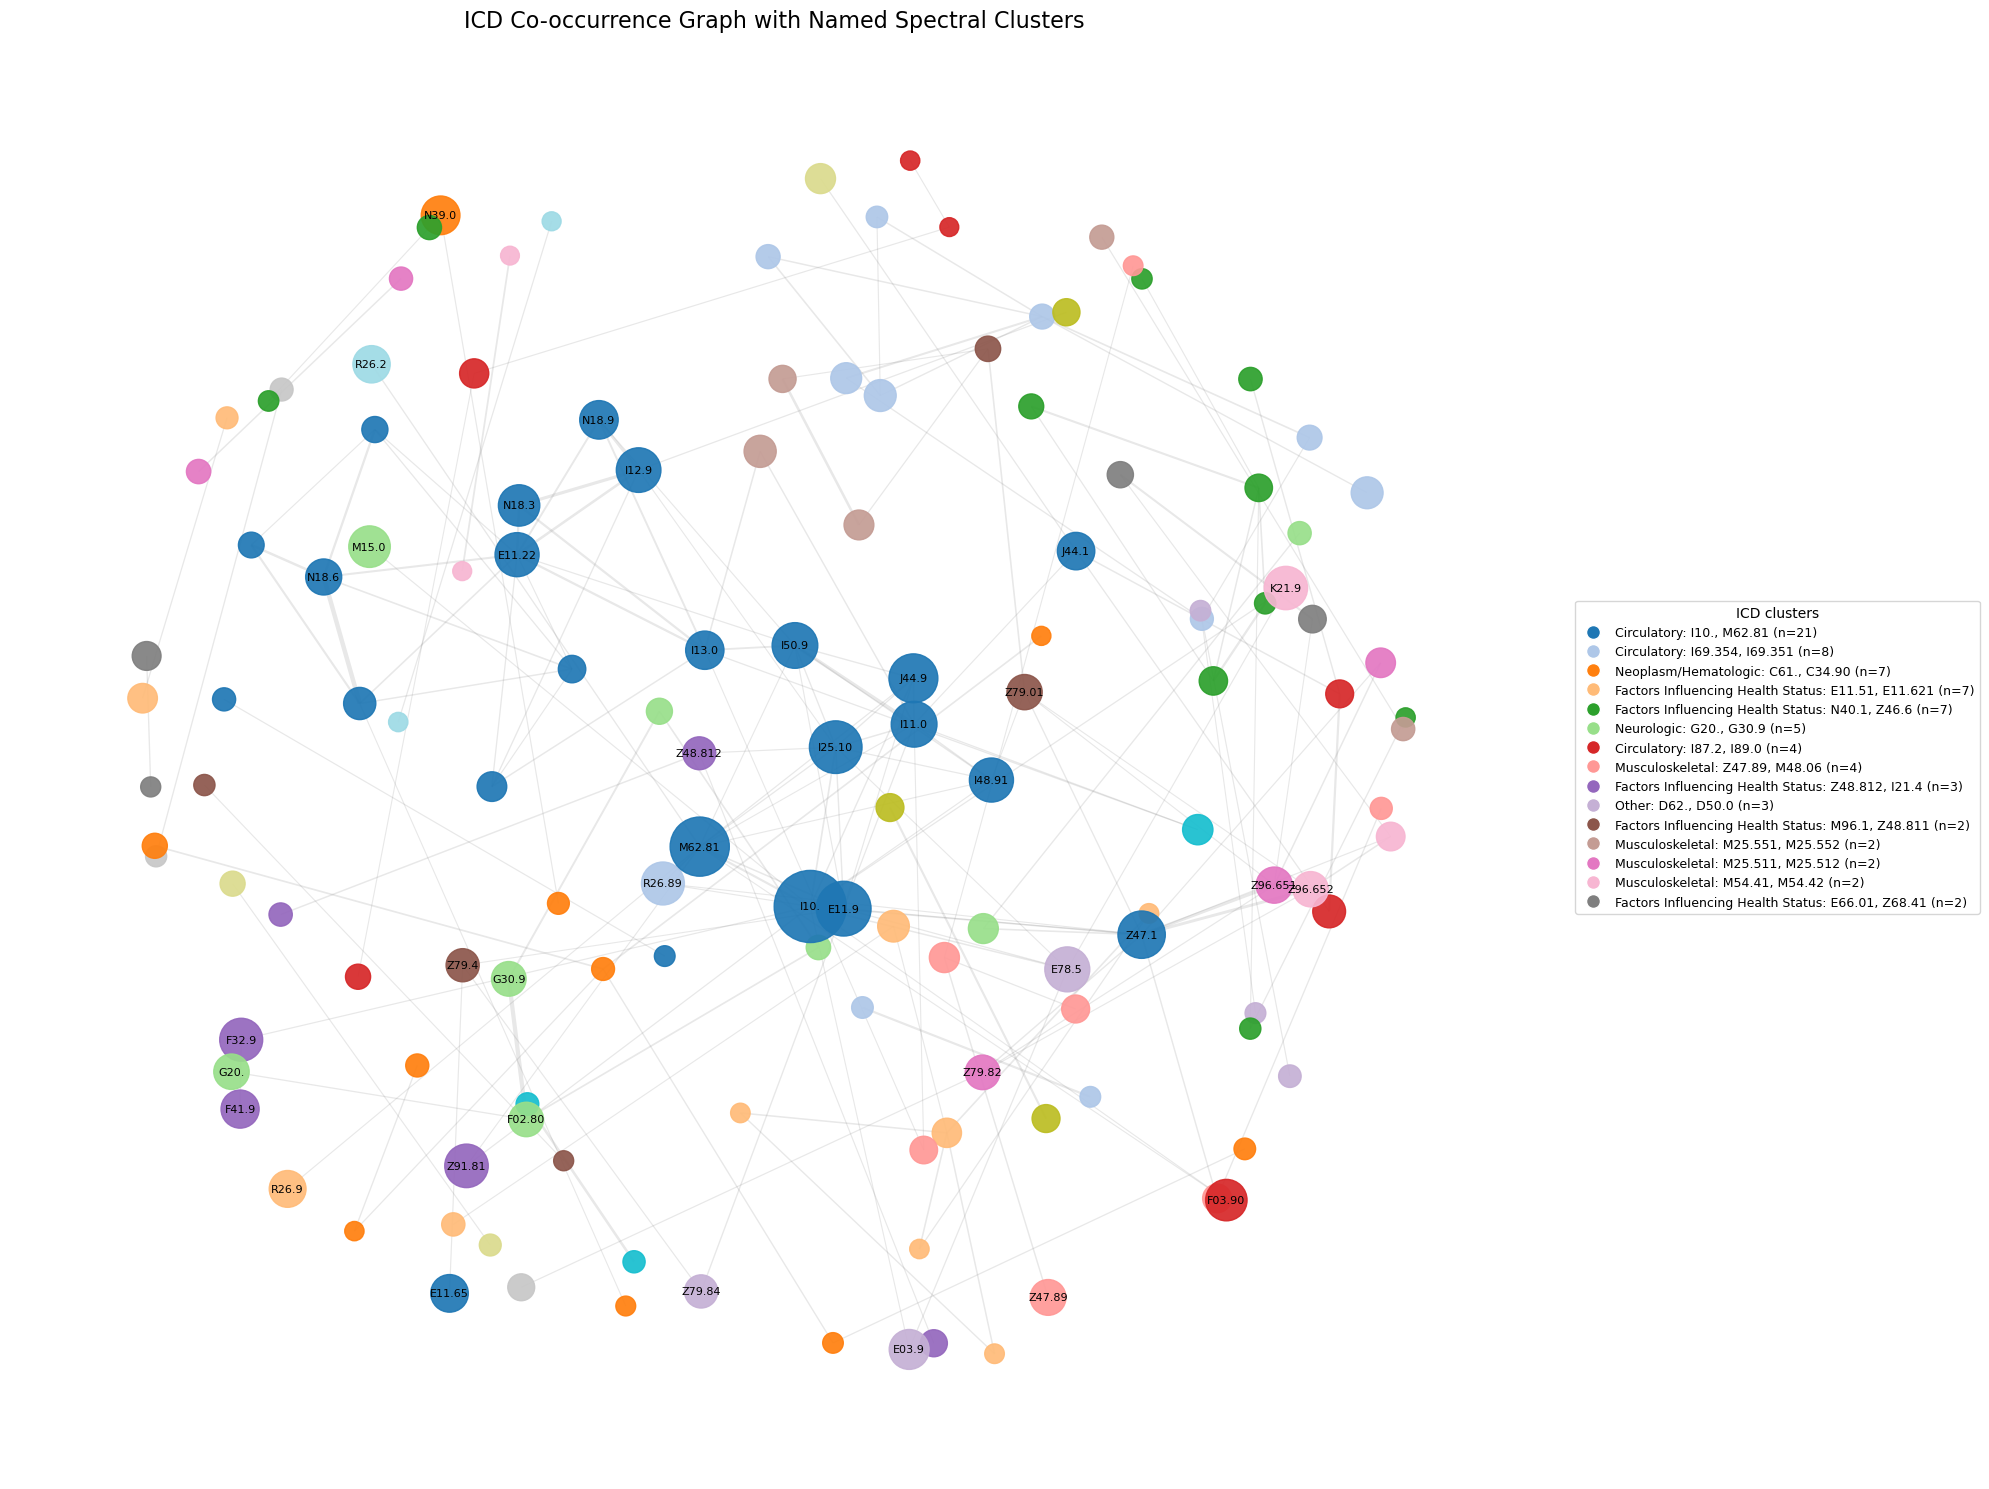

Nodes in full graph: 2689
Edges in full graph: 496
Nodes drawn: 138
Edges drawn: 179


In [22]:
# =========================
# STEP 8: DRAW GRAPH WITH NAMED LEGEND
# =========================
displayed_nodes_df = code_cluster_df[
    code_cluster_df['ICD_Code'].isin(H.nodes())
].copy()

displayed_nodes_df = displayed_nodes_df[displayed_nodes_df['ICD_Cluster'] != -1]

cluster_counts = (
    displayed_nodes_df
    .groupby('ICD_Cluster', as_index=True)['ICD_Code']
    .count()
    .sort_values(ascending=False)
)

cluster_ids = cluster_counts.index.tolist()
cmap = plt.colormaps['tab20']
cluster_to_color = {cl: cmap(i % 20) for i, cl in enumerate(cluster_ids)}
default_color = 'lightgray'

node_colors = [
    cluster_to_color.get(H.nodes[n]['cluster'], default_color)
    for n in H.nodes()
]
node_sizes = [20 + 8 * np.sqrt(H.nodes[n]['frequency']) for n in H.nodes()]
edge_widths = [0.5 + 6 * H[u][v]['weight'] for u, v in H.edges()]

fig, ax = plt.subplots(figsize=(20, 15))
pos = nx.spring_layout(H, k=0.45, seed=RANDOM_STATE, weight='weight', iterations=100)

nx.draw_networkx_edges(
    H, pos,
    alpha=0.18,
    width=edge_widths,
    edge_color='gray',
    ax=ax
)

nx.draw_networkx_nodes(
    H, pos,
    node_size=node_sizes,
    node_color=node_colors,
    alpha=0.92,
    ax=ax
)

label_nodes = (
    displayed_nodes_df
    .sort_values('Code_Frequency', ascending=False)
    .head(TOP_LABELS_TO_DRAW)['ICD_Code']
    .tolist()
)

nx.draw_networkx_labels(
    H, pos,
    labels={n: n for n in label_nodes if n in H.nodes()},
    font_size=8,
    ax=ax
)

cluster_name_lookup = (
    displayed_nodes_df
    .drop_duplicates('ICD_Cluster')
    .set_index('ICD_Cluster')['ICD_Cluster_Name']
    .to_dict()
)

legend_handles = []
for cl, count in cluster_counts.items():
    color = cluster_to_color.get(cl, default_color)
    label = cluster_name_lookup.get(cl, f'Cluster {cl}')
    handle = Line2D(
        [0], [0],
        marker='o',
        color='w',
        label=f'{label} (n={count})',
        markerfacecolor=color,
        markersize=10
    )
    legend_handles.append(handle)

legend_handles = legend_handles[:MAX_LEGEND_ITEMS]

if legend_handles:
    ax.legend(
        handles=legend_handles,
        title='ICD clusters',
        loc='center left',
        bbox_to_anchor=(1.02, 0.5),
        frameon=True,
        fontsize=9,
        title_fontsize=10
    )

ax.set_title("ICD Co-occurrence Graph with Named Spectral Clusters", fontsize=16)
ax.axis('off')
plt.tight_layout()
plt.show()\

print("Nodes in full graph:", G.number_of_nodes())
print("Edges in full graph:", G.number_of_edges())
print("Nodes drawn:", H.number_of_nodes())
print("Edges drawn:", H.number_of_edges())

In [23]:
top_codes_per_cluster = (
    code_cluster_df[code_cluster_df['ICD_Cluster'] != -1]
    .sort_values(['ICD_Cluster', 'Code_Frequency'], ascending=[True, False])
    .groupby(['ICD_Cluster', 'ICD_Cluster_Name'])
    .head(15)
    .reset_index(drop=True)
)

cluster_summary = (
    top_codes_per_cluster
    .groupby(['ICD_Cluster', 'ICD_Cluster_Name'])
    .agg(
        Num_Codes=('ICD_Code', 'count'),
        Total_Code_Frequency=('Code_Frequency', 'sum'),
        Top_Codes=('ICD_Code', lambda s: ", ".join(s.head(5)))
    )
    .reset_index()
    .sort_values('Total_Code_Frequency', ascending=False)
)

cluster_summary

,ICD_Cluster,ICD_Cluster_Name,Num_Codes,Total_Code_Frequency,Top_Codes
194,0,"Circulatory: I10., M62.81",15,393018,"I10., M62.81, E11.9, I25.10, J44.9"
209,15,"Endocrine/Metabolic: E78.5, E03.9",2,26661,"E78.5, E03.9"
202,8,"Mental/Behavioral: F32.9, F41.9",2,22143,"F32.9, F41.9"
161,-35,"Neurologic: G20., G30.9",5,20459,"G20., G30.9, F02.80, F02.81, G30.1"
184,-11,"Circulatory: I69.354, I69.351",12,18258,"I69.354, I69.351, R13.10, I69.391, R13.12"
...,...,...,...,...,...
48,-148,"Injury/Toxicity: S12.600D, S12.500D",2,46,"S12.600D, S12.500D"
95,-101,"Musculoskeletal: M13.862, M13.861",2,45,"M13.862, M13.861"
41,-155,"Injury/Toxicity: S32.049D, S32.059D",2,45,"S32.049D, S32.059D"
179,-16,"Neoplasm/Hematologic: C56.1, C56.2",2,43,"C56.1, C56.2"


In [24]:
# =========================
# STEP 9: MAP BACK TO ORIGINAL DF
# =========================
for c in icdcols:
    work[c + '_Cluster'] = work[c].map(code_to_cluster).fillna(-1).astype(int)
    work[c + '_Cluster_Name'] = work[c].map(code_to_cluster_name).fillna("Isolated / Unclustered")

# optional row-level summaries
cluster_cols = [c + '_Cluster' for c in icdcols]
cluster_name_cols = [c + '_Cluster_Name' for c in icdcols]

def row_clusters(row):
    vals = []
    for c in cluster_cols:
        v = row[c]
        if pd.notna(v) and int(v) != -1:
            vals.append(int(v))
    return sorted(set(vals))

def row_cluster_names(row):
    vals = []
    for c in cluster_name_cols:
        v = row[c]
        if pd.notna(v) and v != "Isolated / Unclustered":
            vals.append(v)
    return sorted(set(vals))

work['ICD_Clusters_In_Row'] = work.apply(row_clusters, axis=1)
work['ICD_Cluster_Names_In_Row'] = work.apply(row_cluster_names, axis=1)

# optional: if you want to drop raw ICD columns after mapping
work_no_raw_icd = work.drop(columns=icdcols)
work_no_raw_icd

,Beneficiary_ID,Assessment_Effective_Date,Submitted_HIPPS_Code,Facility_Internal_ID,Age,Gender,American_Indian_or_Alaska_Native,Asian,Black_or_African_American,Hispanic_or_Latino,Native_Hawiian_or_Pacific_Islander,White,ByDiscipline,Days_Cared_For,Patient_ZIP_Code,STATE_ID,Agency_Medicare_Number,has_diabetes,has_heart_failure,has_hypertension,ever_deceased,ever_readmitted,BMI,BMI_Category,charlson_score,charlson_ageadj,charlson_survival_10yr,elix_quan_score,elix_quan_ageadj,elix_swiss_score,elix_swiss_ageadj,aids,alcohol,ami,blane,canc,carit,cevd,chf,coag,copd,dane,dementia,depre,diab,diabc,diabunc,diabwc,drug,fed,hp,hypc,hypothy,hypunc,ld,lymph,metacanc,msld,obes,ond,pcd,psycho,pud,pvd,rend,rheumd,valv,wloss,Primary_Diagnosis_ICD_10_C_M_Code_Cluster,Primary_Diagnosis_ICD_10_C_M_Code_Cluster_Name,Other_Diagnosis_Code_1_ICD_10_C_M_Cluster,Other_Diagnosis_Code_1_ICD_10_C_M_Cluster_Name,Other_Diagnosis_Code_2_ICD_10_C_M_Cluster,Other_Diagnosis_Code_2_ICD_10_C_M_Cluster_Name,Other_Diagnosis_Code_3_ICD_10_C_M_Cluster,Other_Diagnosis_Code_3_ICD_10_C_M_Cluster_Name,Other_Diagnosis_Code_4_ICD_10_C_M_Cluster,Other_Diagnosis_Code_4_ICD_10_C_M_Cluster_Name,Other_Diagnosis_Code_5_ICD_10_C_M_Cluster,Other_Diagnosis_Code_5_ICD_10_C_M_Cluster_Name,ICD_Clusters_In_Row,ICD_Cluster_Names_In_Row
0,GGGGGGG99DzGeze,2017-03-17,1AGKU,334582,46,Female,0,0,1,0,0,0,RN,25,77037,TX,677994,0,0,0,1,1,29.898299,Overweight,4.0,4.0,0.533915,9.0,9.0,18.0,18.0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,-1,Isolated / Unclustered,-141,"Symptoms/Signs: R10.11, R10.31",2,Genitourinary: N18.5,-1,Isolated / Unclustered,26,"Factors Influencing Health Status: Z45.2, Z79.2",0,"Circulatory: I10., M62.81","[-141, 0, 2, 26]","[Circulatory: I10., M62.81, Factors Influencin..."
1,GGGGGGG9DDWNGGz,2017-02-28,2CGKU,487590,74,Female,0,0,0,0,0,1,RN,54,750447553,TX,679724,0,0,0,1,0,33.197222,Obese-Class1,1.0,4.0,0.533915,3.0,6.0,0.0,3.0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,"Circulatory: I10., M62.81",-1,Isolated / Unclustered,-1,Isolated / Unclustered,0,"Circulatory: I10., M62.81",0,"Circulatory: I10., M62.81",15,"Endocrine/Metabolic: E78.5, E03.9","[0, 15]","[Circulatory: I10., M62.81, Endocrine/Metaboli..."
2,GGGGGGG9DDWWeeX,2017-10-22,1CHKS,63847,75,Male,0,0,0,0,0,1,RN,37,75070,TX,679236,0,0,0,1,0,27.194009,Overweight,1.0,4.0,0.533915,0.0,3.0,0.0,3.0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4,"Factors Influencing Health Status: Z48.812, I21.4",-1,Isolated / Unclustered,-1,Isolated / Unclustered,0,"Circulatory: I10., M62.81",0,"Circulatory: I10., M62.81",21,Mental/Behavioral: F03.90,"[0, 4, 21]","[Circulatory: I10., M62.81, Factors Influencin..."
3,GGGGGGG9DGXzUSG,2017-09-13,1BHKT,10206,75,Male,0,0,0,0,0,1,RN,57,77975,TX,677247,0,0,0,0,0,22.594123,Normal weight,0.0,3.0,0.774816,0.0,3.0,0.0,3.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-1,Isolated / Unclustered,26,"Factors Influencing Health Status: Z45.2, Z79.2",0,"Circulatory: I10., M62.81",-108,"Musculoskeletal: M21.371, M21.372",-108,"Musculoskeletal: M21.371, M21.372",-1,Isolated / Unclustered,"[-108, 0, 26]","[Circulatory: I10., M62.81, Factors Influencin..."
4,GGGGGGG9DSUDeNG,2017-10-20,5AGKS,17490,75,Male,0,0,0,1,0,0,RN,55,78250,TX,679044,0,0,0,0,0,25.014922,Overweight,0.0,3.0,0.774816,0.0,3.0,0.0,3.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,"Circulatory: I10., M62.81",-1,Isolated / Unclustered,-1,Isolated / Unclustered,-146,"Injury/Toxicity: S06.5X9D, S06.6X9D",-1,Isolated / Unclustered,-1,Isolated / Unclustered,"[-146, 0]","[Circulatory: I10., M62.81, Injury/Toxicity: S..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,

In [25]:
work_no_raw_icd.to_csv("data/oasis_clusteredICD_TX.csv", index=False)

In [26]:
oasis_df = work_no_raw_icd.copy()

oasis_df['zip'] = (
    oasis_df['Patient_ZIP_Code']
    .astype(str)
    .str.strip()
    .str[:5]
)
oasis_df['state_id'] = oasis_df['STATE_ID'].astype(str).str.strip().str.upper()
oasis_df.drop(['STATE_ID', 'Patient_ZIP_Code'], axis=1, inplace=True)

In [27]:
oasis_df

,Beneficiary_ID,Assessment_Effective_Date,Submitted_HIPPS_Code,Facility_Internal_ID,Age,Gender,American_Indian_or_Alaska_Native,Asian,Black_or_African_American,Hispanic_or_Latino,Native_Hawiian_or_Pacific_Islander,White,ByDiscipline,Days_Cared_For,Agency_Medicare_Number,has_diabetes,has_heart_failure,has_hypertension,ever_deceased,ever_readmitted,BMI,BMI_Category,charlson_score,charlson_ageadj,charlson_survival_10yr,elix_quan_score,elix_quan_ageadj,elix_swiss_score,elix_swiss_ageadj,aids,alcohol,ami,blane,canc,carit,cevd,chf,coag,copd,dane,dementia,depre,diab,diabc,diabunc,diabwc,drug,fed,hp,hypc,hypothy,hypunc,ld,lymph,metacanc,msld,obes,ond,pcd,psycho,pud,pvd,rend,rheumd,valv,wloss,Primary_Diagnosis_ICD_10_C_M_Code_Cluster,Primary_Diagnosis_ICD_10_C_M_Code_Cluster_Name,Other_Diagnosis_Code_1_ICD_10_C_M_Cluster,Other_Diagnosis_Code_1_ICD_10_C_M_Cluster_Name,Other_Diagnosis_Code_2_ICD_10_C_M_Cluster,Other_Diagnosis_Code_2_ICD_10_C_M_Cluster_Name,Other_Diagnosis_Code_3_ICD_10_C_M_Cluster,Other_Diagnosis_Code_3_ICD_10_C_M_Cluster_Name,Other_Diagnosis_Code_4_ICD_10_C_M_Cluster,Other_Diagnosis_Code_4_ICD_10_C_M_Cluster_Name,Other_Diagnosis_Code_5_ICD_10_C_M_Cluster,Other_Diagnosis_Code_5_ICD_10_C_M_Cluster_Name,ICD_Clusters_In_Row,ICD_Cluster_Names_In_Row,zip,state_id
0,GGGGGGG99DzGeze,2017-03-17,1AGKU,334582,46,Female,0,0,1,0,0,0,RN,25,677994,0,0,0,1,1,29.898299,Overweight,4.0,4.0,0.533915,9.0,9.0,18.0,18.0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,-1,Isolated / Unclustered,-141,"Symptoms/Signs: R10.11, R10.31",2,Genitourinary: N18.5,-1,Isolated / Unclustered,26,"Factors Influencing Health Status: Z45.2, Z79.2",0,"Circulatory: I10., M62.81","[-141, 0, 2, 26]","[Circulatory: I10., M62.81, Factors Influencin...",77037,TX
1,GGGGGGG9DDWNGGz,2017-02-28,2CGKU,487590,74,Female,0,0,0,0,0,1,RN,54,679724,0,0,0,1,0,33.197222,Obese-Class1,1.0,4.0,0.533915,3.0,6.0,0.0,3.0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,"Circulatory: I10., M62.81",-1,Isolated / Unclustered,-1,Isolated / Unclustered,0,"Circulatory: I10., M62.81",0,"Circulatory: I10., M62.81",15,"Endocrine/Metabolic: E78.5, E03.9","[0, 15]","[Circulatory: I10., M62.81, Endocrine/Metaboli...",75044,TX
2,GGGGGGG9DDWWeeX,2017-10-22,1CHKS,63847,75,Male,0,0,0,0,0,1,RN,37,679236,0,0,0,1,0,27.194009,Overweight,1.0,4.0,0.533915,0.0,3.0,0.0,3.0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4,"Factors Influencing Health Status: Z48.812, I21.4",-1,Isolated / Unclustered,-1,Isolated / Unclustered,0,"Circulatory: I10., M62.81",0,"Circulatory: I10., M62.81",21,Mental/Behavioral: F03.90,"[0, 4, 21]","[Circulatory: I10., M62.81, Factors Influencin...",75070,TX
3,GGGGGGG9DGXzUSG,2017-09-13,1BHKT,10206,75,Male,0,0,0,0,0,1,RN,57,677247,0,0,0,0,0,22.594123,Normal weight,0.0,3.0,0.774816,0.0,3.0,0.0,3.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-1,Isolated / Unclustered,26,"Factors Influencing Health Status: Z45.2, Z79.2",0,"Circulatory: I10., M62.81",-108,"Musculoskeletal: M21.371, M21.372",-108,"Musculoskeletal: M21.371, M21.372",-1,Isolated / Unclustered,"[-108, 0, 26]","[Circulatory: I10., M62.81, Factors Influencin...",77975,TX
4,GGGGGGG9DSUDeNG,2017-10-20,5AGKS,17490,75,Male,0,0,0,1,0,0,RN,55,679044,0,0,0,0,0,25.014922,Overweight,0.0,3.0,0.774816,0.0,3.0,0.0,3.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,"Circulatory: I10., M62.81",-1,Isolated / Unclustered,-1,Isolated / Unclustered,-146,"Injury/Toxicity: S06.5X9D, S06.6X9D",-1,Isolated / Unclustered,-1,Isolated / Unclustered,"[-146, 0]","[Circulatory: I10., M62.81, Injury/Toxicity: S...",78250,TX
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,.

In [28]:
# SDOH ZIP–census file
sdoh_zip_census = pd.read_csv("data/sdoh_zips_census_TX.csv").drop_duplicates().dropna()
#(50987, 74)
print(sdoh_zip_census.shape)
sdoh_zip_census

(50987, 74)


,zip,city,state_id,state_name,COUNTY_NAME,POP_URB,POPPCT_URB,POP_RUR,POPPCT_RUR,COUNTYFIPS,ACS_PCT_BACHELOR_DGR,ACS_PCT_COLLEGE_ASSOCIATE_DGR,ACS_PCT_GRADUATE_DGR,ACS_PCT_HS_GRADUATE,ACS_PCT_LT_HS,ACS_PCT_NO_WORK_NO_SCHL_16_19,ACS_PCT_POSTHS_ED,ACS_PCT_VET_BACHELOR,ACS_PCT_VET_COLLEGE,ACS_PCT_VET_HS,ACS_PCT_HH_LIMIT_ENGLISH,ACS_PCT_HH_BROADBAND,ACS_PCT_HH_BROADBAND_ONLY,ACS_PCT_HH_CELLULAR,ACS_PCT_HH_CELLULAR_ONLY,ACS_PCT_HH_DIAL_INTERNET_ONLY,ACS_PCT_HH_INTERNET,ACS_PCT_HH_INTERNET_NO_SUBS,ACS_PCT_HH_NO_COMP_DEV,ACS_PCT_HH_NO_INTERNET,ACS_PCT_HH_OTHER_COMP,ACS_PCT_HH_OTHER_COMP_ONLY,ACS_PCT_HH_PC,ACS_PCT_HH_PC_ONLY,ACS_PCT_HH_SAT_INTERNET,ACS_PCT_HH_SMARTPHONE,ACS_PCT_HH_SMARTPHONE_ONLY,ACS_PCT_HH_TABLET,ACS_PCT_HH_TABLET_ONLY,ACS_PCT_CHILDREN_GRANDPARENT,ACS_PCT_CHILD_1FAM,ACS_PCT_GRANDP_NO_RESPS,ACS_PCT_GRANDP_RESPS_NO_P,ACS_PCT_GRANDP_RESPS_P,ACS_PCT_HH_1PERS,ACS_PCT_HH_ABOVE65,ACS_PCT_HH_ALONE_ABOVE65,ACS_PCT_HH_KID_1PRNT,ACS_TOT_GRANDCHILDREN_GP,ACS_PCT_HEALTH_INC_138_199,ACS_PCT_HEALTH_INC_200_399,ACS_PCT_HEALTH_INC_ABOVE400,ACS_PCT_HEALTH_INC_BELOW137,ACS_PCT_HH_1FAM_FOOD_STMP,ACS_PCT_HH_FOOD_STMP_BLW_POV,ACS_PCT_HH_NO_FD_STMP_BLW_POV,ACS_PCT_HH_PUB_ASSIST,ACS_PCT_INC50,ACS_PCT_INC50_ABOVE65,ACS_PCT_NONVET_POV_18_64,ACS_PCT_PERSON_INC_100_124,ACS_PCT_PERSON_INC_125_199,ACS_PCT_PERSON_INC_ABOVE200,ACS_PCT_PERSON_INC_BELOW99,ACS_PCT_POV_AIAN,ACS_PCT_POV_ASIAN,ACS_PCT_POV_BLACK,ACS_PCT_POV_HISPANIC,ACS_PCT_POV_MULTI,ACS_PCT_POV_NHPI,ACS_PCT_POV_OTHER,ACS_PCT_POV_WHITE,ACS_PCT_VET_POV_18_64,ACS_TOT_POP_POV
0,75763,Frankston,TX,Texas,Anderson,0.0,0.00,7836.0,100.00,20003,10.365000,29.920000,7.170000,41.025000,11.515000,4.520000,47.460000,18.080000,19.050000,62.870000,1.120000,45.850000,11.815000,55.280000,13.295000,0.890000,70.980000,7.660000,15.20000,21.360000,2.325000,0.045000,67.535000,8.980000,13.850000,68.430000,11.355000,49.130000,3.230000,10.905000,21.390000,19.710000,30.070000,50.220000,28.645000,34.770000,12.745000,16.570000,124.000000,10.255000,40.130000,27.490000,22.135000,36.395000,3.540000,10.500000,12.280000,4.540000,3.460000,13.685000,5.950000,11.595000,67.650000,14.805000,8.335000,0.000000,50.000000,66.345000,20.970000,0.000000,0.000000,13.760000,7.405000,3860.000000
1,75763,Frankston,TX,Texas,Anderson,0.0,0.00,7836.0,100.00,21005,14.665000,32.395000,8.280000,35.245000,9.413333,0.736667,55.340000,28.996667,33.803333,37.201667,0.000000,47.370000,5.228333,72.048333,20.471667,0.191667,80.806667,2.871667,11.91500,16.320000,1.225000,0.000000,70.650000,5.053333,15.025000,79.686667,10.383333,56.385000,1.643333,14.980000,25.100000,42.020000,17.373333,40.606667,25.500000,31.763333,11.175000,15.386667,87.500000,12.373333,32.163333,34.748333,20.715000,15.461667,4.895000,7.765000,10.136667,6.245000,3.505000,16.195000,3.706667,14.238333,66.911667,15.146667,0.000000,0.000000,27.773333,21.923333,31.685000,0.000000,0.000000,13.476667,8.738333,3721.166667
2,75763,Frankston,TX,Texas,Anderson,0.0,0.00,7836.0,100.00,45007,14.244314,31.171765,8.335882,31.285686,14.962353,3.965294,53.752353,21.048039,37.957647,40.994706,0.674314,60.758824,7.661569,70.916471,14.975490,0.088235,79.756078,3.293137,10.81098,16.950784,2.861569,0.048824,70.073137,5.143529,6.901569,80.687255,11.490784,58.552157,1.396275,11.974118,31.691373,43.855490,24.061961,24.239020,27.293922,32.953529,12.203529,18.329216,110.784314,12.969804,33.157843,30.707647,23.165098,23.877843,6.178039,7.190196,12.567647,6.091569,2.692353,13.261961,6.397451,15.753333,63.836275,14.014314,6.002745,5.698235,21.098039,19.613725,20.439216,1.960784,14.176078,11.945098,9.738431,3868.980392
3,75763,Frankston,TX,Texas,Anderson,0.0,0.00,7836.0,100.00,47001,12.028000,29.764500,9.444500,33.084500,10.676500,1.679000,51.239500,20.862000,37.505500,36.633500,0.634000,61.107500,9.210500,69.087000,11.530500,0.429000,79.938500,2.317500,9.96000,12.745000,1.933500,0.021000,68.533500,4.817500,4.831500,75.632000,10.539500,56.170500,1.547000,10.767500,27.910000,27.403500,29.474500,33.122500,24.625500,3

In [29]:
sdoh_df = sdoh_zip_census.copy()
sdoh_df['zip'] = sdoh_df['zip'].astype(str)

# normalize state_id to uppercase string
sdoh_df['state_id'] = sdoh_df['state_id'].astype(str).str.strip().str.upper()

In [30]:
sdoh_df.dtypes

zip                       object
city                      object
state_id                  object
state_name                object
COUNTY_NAME               object
                          ...   
ACS_PCT_POV_NHPI         float64
ACS_PCT_POV_OTHER        float64
ACS_PCT_POV_WHITE        float64
ACS_PCT_VET_POV_18_64    float64
ACS_TOT_POP_POV          float64
Length: 74, dtype: object

In [31]:
merged = oasis_df.merge(
    sdoh_df,
    how='left',
    on=['state_id', 'zip']
)
merged.drop_duplicates(subset=['Beneficiary_ID'], keep='first', inplace=True)

print(merged.shape)
merged

(233273, 154)


,Beneficiary_ID,Assessment_Effective_Date,Submitted_HIPPS_Code,Facility_Internal_ID,Age,Gender,American_Indian_or_Alaska_Native,Asian,Black_or_African_American,Hispanic_or_Latino,Native_Hawiian_or_Pacific_Islander,White,ByDiscipline,Days_Cared_For,Agency_Medicare_Number,has_diabetes,has_heart_failure,has_hypertension,ever_deceased,ever_readmitted,BMI,BMI_Category,charlson_score,charlson_ageadj,charlson_survival_10yr,elix_quan_score,elix_quan_ageadj,elix_swiss_score,elix_swiss_ageadj,aids,alcohol,ami,blane,canc,carit,cevd,chf,coag,copd,dane,dementia,depre,diab,diabc,diabunc,diabwc,drug,fed,hp,hypc,hypothy,hypunc,ld,lymph,metacanc,msld,obes,ond,pcd,psycho,pud,pvd,rend,rheumd,valv,wloss,Primary_Diagnosis_ICD_10_C_M_Code_Cluster,Primary_Diagnosis_ICD_10_C_M_Code_Cluster_Name,Other_Diagnosis_Code_1_ICD_10_C_M_Cluster,Other_Diagnosis_Code_1_ICD_10_C_M_Cluster_Name,Other_Diagnosis_Code_2_ICD_10_C_M_Cluster,Other_Diagnosis_Code_2_ICD_10_C_M_Cluster_Name,Other_Diagnosis_Code_3_ICD_10_C_M_Cluster,Other_Diagnosis_Code_3_ICD_10_C_M_Cluster_Name,Other_Diagnosis_Code_4_ICD_10_C_M_Cluster,Other_Diagnosis_Code_4_ICD_10_C_M_Cluster_Name,Other_Diagnosis_Code_5_ICD_10_C_M_Cluster,Other_Diagnosis_Code_5_ICD_10_C_M_Cluster_Name,ICD_Clusters_In_Row,ICD_Cluster_Names_In_Row,zip,state_id,city,state_name,COUNTY_NAME,POP_URB,POPPCT_URB,POP_RUR,POPPCT_RUR,COUNTYFIPS,ACS_PCT_BACHELOR_DGR,ACS_PCT_COLLEGE_ASSOCIATE_DGR,ACS_PCT_GRADUATE_DGR,ACS_PCT_HS_GRADUATE,ACS_PCT_LT_HS,ACS_PCT_NO_WORK_NO_SCHL_16_19,ACS_PCT_POSTHS_ED,ACS_PCT_VET_BACHELOR,ACS_PCT_VET_COLLEGE,ACS_PCT_VET_HS,ACS_PCT_HH_LIMIT_ENGLISH,ACS_PCT_HH_BROADBAND,ACS_PCT_HH_BROADBAND_ONLY,ACS_PCT_HH_CELLULAR,ACS_PCT_HH_CELLULAR_ONLY,ACS_PCT_HH_DIAL_INTERNET_ONLY,ACS_PCT_HH_INTERNET,ACS_PCT_HH_INTERNET_NO_SUBS,ACS_PCT_HH_NO_COMP_DEV,ACS_PCT_HH_NO_INTERNET,ACS_PCT_HH_OTHER_COMP,ACS_PCT_HH_OTHER_COMP_ONLY,ACS_PCT_HH_PC,ACS_PCT_HH_PC_ONLY,ACS_PCT_HH_SAT_INTERNET,ACS_PCT_HH_SMARTPHONE,ACS_PCT_HH_SMARTPHONE_ONLY,ACS_PCT_HH_TABLET,ACS_PCT_HH_TABLET_ONLY,ACS_PCT_CHILDREN_GRANDPARENT,ACS_PCT_CHILD_1FAM,ACS_PCT_GRANDP_NO_RESPS,ACS_PCT_GRANDP_RESPS_NO_P,ACS_PCT_GRANDP_RESPS_P,ACS_PCT_HH_1PERS,ACS_PCT_HH_ABOVE65,ACS_PCT_HH_ALONE_ABOVE65,ACS_PCT_HH_KID_1PRNT,ACS_TOT_GRANDCHILDREN_GP,ACS_PCT_HEALTH_INC_138_199,ACS_PCT_HEALTH_INC_200_399,ACS_PCT_HEALTH_INC_ABOVE400,ACS_PCT_HEALTH_INC_BELOW137,ACS_PCT_HH_1FAM_FOOD_STMP,ACS_PCT_HH_FOOD_STMP_BLW_POV,ACS_PCT_HH_NO_FD_STMP_BLW_POV,ACS_PCT_HH_PUB_ASSIST,ACS_PCT_INC50,ACS_PCT_INC50_ABOVE65,ACS_PCT_NONVET_POV_18_64,ACS_PCT_PERSON_INC_100_124,ACS_PCT_PERSON_INC_125_199,ACS_PCT_PERSON_INC_ABOVE200,ACS_PCT_PERSON_INC_BELOW99,ACS_PCT_POV_AIAN,ACS_PCT_POV_ASIAN,ACS_PCT_POV_BLACK,ACS_PCT_POV_HISPANIC,ACS_PCT_POV_MULTI,ACS_PCT_POV_NHPI,ACS_PCT_POV_OTHER,ACS_PCT_POV_WHITE,ACS_PCT_VET_POV_18_64,ACS_TOT_POP_POV
0,GGGGGGG99DzGeze,2017-03-17,1AGKU,334582,46,Female,0,0,1,0,0,0,RN,25,677994,0,0,0,1,1,29.898299,Overweight,4.0,4.0,0.533915,9.0,9.0,18.0,18.0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,-1,Isolated / Unclustered,-141,"Symptoms/Signs: R10.11, R10.31",2,Genitourinary: N18.5,-1,Isolated / Unclustered,26,"Factors Influencing Health Status: Z45.2, Z79.2",0,"Circulatory: I10., M62.81","[-141, 0, 2, 26]","[Circulatory: I10., M62.81, Factors Influencin...",77037,TX,Houston,Texas,Harris,974.0,2.81,33694.0,97.19,13145.0,18.742857,36.044286,13.007143,25.427143,6.781429,1.932857,67.791429,34.930000,43.618571,21.450000,0.141429,67.004286,7.255714,75.972857,12.107143,0.292857,85.781429,1.478571,5.607143,12.738571,2.675714,0.000000,81.012857,4.245714,9.700000,86.352857,9.494286,68.822857,0.477143,9.277143,17.435714,40.381429,18.250000,41.368571,18.477143,33.230000,8.747143,11.338571,91.571429,9.890000,32.284286,47.674286,10.150000,25.710000,2.957143,2.585714,7.870000,3.257143,1.658571,5.768571,2.601429,11.638571,79.958571,5.800000,0.000000,2.844286,5.634286,3.997143,6.295714,0.000000,0.000000,5.320000,0.817143,4868.571429
4,GGGGGGG9DDWNGGz,2017-02-28,2CGKU,48

In [32]:
merged.columns.tolist()

['Beneficiary_ID',
 'Assessment_Effective_Date',
 'Submitted_HIPPS_Code',
 'Facility_Internal_ID',
 'Age',
 'Gender',
 'American_Indian_or_Alaska_Native',
 'Asian',
 'Black_or_African_American',
 'Hispanic_or_Latino',
 'Native_Hawiian_or_Pacific_Islander',
 'White',
 'ByDiscipline',
 'Days_Cared_For',
 'Agency_Medicare_Number',
 'has_diabetes',
 'has_heart_failure',
 'has_hypertension',
 'ever_deceased',
 'ever_readmitted',
 'BMI',
 'BMI_Category',
 'charlson_score',
 'charlson_ageadj',
 'charlson_survival_10yr',
 'elix_quan_score',
 'elix_quan_ageadj',
 'elix_swiss_score',
 'elix_swiss_ageadj',
 'aids',
 'alcohol',
 'ami',
 'blane',
 'canc',
 'carit',
 'cevd',
 'chf',
 'coag',
 'copd',
 'dane',
 'dementia',
 'depre',
 'diab',
 'diabc',
 'diabunc',
 'diabwc',
 'drug',
 'fed',
 'hp',
 'hypc',
 'hypothy',
 'hypunc',
 'ld',
 'lymph',
 'metacanc',
 'msld',
 'obes',
 'ond',
 'pcd',
 'psycho',
 'pud',
 'pvd',
 'rend',
 'rheumd',
 'valv',
 'wloss',
 'Primary_Diagnosis_ICD_10_C_M_Code_Cluster'

In [33]:
merged.to_csv('data/final_mergedDF_TX.csv', index=False)